In [6]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx

# pp.config['visualisation']['default_backend'] = 'matplotlib'


## Visualize streamgague locations

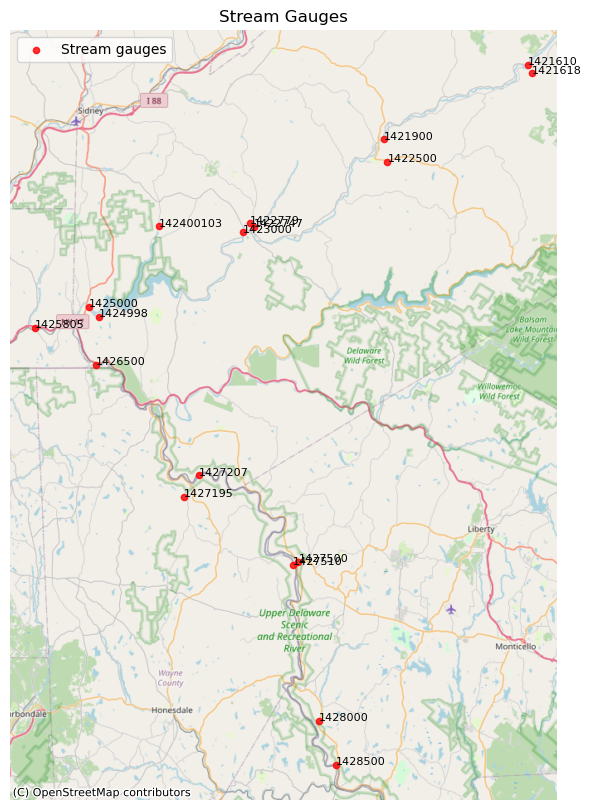

In [8]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_02040101.csv"))

# --- Create geometry from lat/lon ---
geometry = gpd.points_from_xy(metadata["longitude"], metadata["latitude"])
gdf = gpd.GeoDataFrame(metadata, geometry=geometry,crs="EPSG:4326")

# --- Convert to Web Mercator for basemap ---
gdf = gdf.to_crs(epsg=3857)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    label="Stream gauges"
)

# Add basemap 
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.legend(loc="upper left")
# Add labels
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["site_id"]):
    ax.text(x, y, str(label),fontsize=8)

plt.title("Stream Gauges")
plt.show()

## Rename sites and create graph network

In [ ]:
# List of new site names in the order I specified
site_rename_list = [
    "site0", "site1", "site2", "site3", "site4",
    "site6", "site7", "site9", "site11", "site13",
    "site14", "site15", "site16", "site17", "site5",
    "site10", "site12", "site8"
]

metadata["site_rename"] = site_rename_list
metadata[['site_id', 'site_name', 'site_rename']]

,site_id,site_name,site_rename
0,1421610,WEST BRANCH DELAWARE RIVER AT HOBART NY,site0
1,1421618,TOWN BROOK SOUTHEAST OF HOBART NY,site1
2,1421900,WEST BRANCH DELAWARE RIVER UPSTREAM FROM DELHI NY,site2
3,1422500,LITTLE DELAWARE RIVER NEAR DELHI NY,site3
4,1422747,EAST BROOK EAST OF WALTON NY,site4
5,1423000,WEST BRANCH DELAWARE RIVER AT WALTON NY,site6
6,142400103,TROUT CREEK NEAR TROUT CREEK NY,site7
7,1425000,WEST BRANCH DELAWARE RIVER AT STILESVILLE NY,site9
8,1426500,WEST BRANCH DELAWARE RIVER AT HALE EDDY NY,site11
9,1427207,DELAWARE RIVER AT LORDVILLE NY,site13


In [2]:
graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


In [ ]:
river_network = pp.Graph.from_edge_list(graph_edges)

# Print Adjacency matrix to check we created the correct network
A = river_network.sparse_adj_matrix()
print(A.todense())

pp.plot(river_network, node_label = [x for x in river_network.mapping.node_ids])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.